# 🪨 La piedra que aprendió a contar

Una computadora es arena.

Arena a la que le enseñamos a contar.

## 🎯 La promesa

**Hoy vas a abrir tu nombre, tu foto y tu música por dentro, y vas a descubrir
que las tres son la misma cosa: números.**

Y al final vas a armar con el dedo, interruptor por interruptor, la pieza de la
computadora que suma esos números. Esa pieza no tiene ni un solo `+` adentro.

### Cómo se usa

Presiona **`Shift + Enter`** en cada celda, **de arriba abajo y en orden**. Cada
sección usa lo que construiste en la anterior.

Cambia los números. Rompe las cosas. Vuelve a correr. No puedes descomponer nada.

In [2]:
#@title 🔧 Prepara el taller  { display-mode: "form" }
# Corre esta celda y olvidala. Es el escenario, no la obra.
import importlib.util
import subprocess
import sys

from ipywidgets import Widget
from matplotlib.axes import Axes
from matplotlib.figure import Figure as FiguraDeMatplotlib
from plotly.graph_objects import Figure

if importlib.util.find_spec("shift_enter") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/nrqrmz/shift-enter"], check=True)
    importlib.invalidate_caches()

from shift_enter import (cifra, compuertas, imagen, interruptores, paleta,
                         sonido, torre)
from shift_enter.binario import TABLA_DE_VALORES, a_binario, a_decimal

paleta.aplicar_estilo()

# Nada de fijar el renderer de plotly: Colab lo detecta solo, y ponerle
# otro encima es lo que dejaba en blanco la foto por dentro.

# Silencia el eco de las celdas: una figura no debe imprimir su
# representación de texto debajo del dibujo que ya se guardó.
_ip = get_ipython()
if _ip is not None:
    _formateador = _ip.display_formatter.formatters["text/plain"]
    _formateador.for_type(Axes, lambda obj, p, ciclo: p.text(""))
    _formateador.for_type(FiguraDeMatplotlib, lambda obj, p, ciclo: p.text(""))
    _formateador.for_type(Figure, lambda obj, p, ciclo: p.text(""))
    _formateador.for_type(Widget, lambda obj, p, ciclo: p.text(""))

print("Listo. La piedra está encendida.")

Listo. La piedra está encendida.


**Corre esa celda antes que nada.** Trae las herramientas. Es el escenario, no la obra.

---

# 1 · Tu nombre es una lista de números

Escribe tu nombre. Está guardado en esta computadora ahorita mismo.

No como letras. Aquí adentro no hay letras. Solo hay números.

In [3]:
mi_nombre = "Fernanda"    # ← pon el tuyo

for letra in mi_nombre:
    print(letra, "→", ord(letra))

F → 70
e → 101
r → 114
n → 110
a → 97
n → 110
d → 100
a → 97


Ese número no es un apodo ni una traducción. **Es** la letra. Es lo único que
hay de tu nombre dentro de la máquina.

Puedes volver a esa celda cuando quieras, poner otro nombre y correr otra vez
de ahí para abajo. Todo lo que sigue se hace con el nombre que dejes escrito.

Y si tu nombre es una lista de números, entonces se puede escuchar.

In [4]:
sonido.reproducir(sonido.melodia_del_nombre(mi_nombre))

### 🔧 Prueba tú

Ahora súmale un número a cada letra de tu nombre y mira qué sale. El `salto` de
aquí abajo dice cuántos lugares se recorre cada letra. Cámbialo y vuelve a
correr la celda.

In [5]:
salto = 3    # ← cámbialo

secreto = cifra.correr(mi_nombre, salto)
print("   cifrado:   ", secreto)
print("   descifrado:", cifra.correr(secreto, -salto))

   cifrado:    Ihuqdqgd
   descifrado: Fernanda


Julio César mandaba sus órdenes militares así, hace dos mil años. Le sumaba un
número a cada letra, y quien interceptaba el mensaje se quedaba viendo letras
que no decían nada.

Tú lo acabas de hacer con una suma.

### 🎯 El reto

Aquí hay un mensaje cifrado. Nadie te va a decir con qué número.

Arrastra el salto hasta que el mensaje se vuelva español.

In [6]:
cifra.deslizador_disco(cifra.MENSAJE_RETO)

### 🤔 Para pensar

El espacio también se convirtió en otro símbolo cuando corriste las letras.

¿Por qué? ¿Qué número crees que es un espacio?

---

# 2 · Tu foto es una tabla de números

Tu nombre era una lista. Una imagen es una tabla: un número por cada punto de
la pantalla.

Empieza al revés. En vez de abrir una foto, dibuja una escribiendo. Cada `#` es
un punto negro y cada `.` uno blanco.

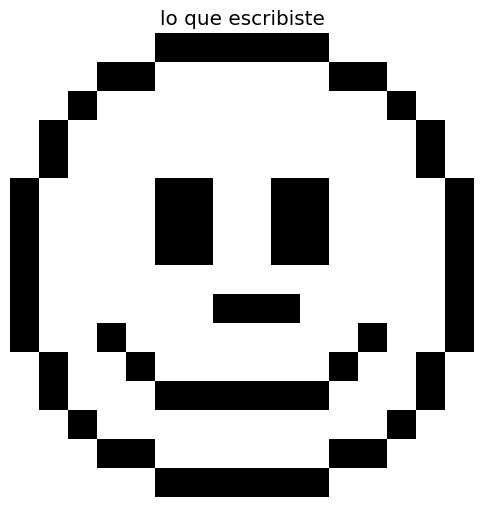

In [8]:
mi_dibujo = """
.....######.....
...##......##...
..#..........#..
.#............#.
.#............#.
#....##..##....#
#....##..##....#
#....##..##....#
#..............#
#......###.....#
#..#........#..#
.#..#......#..#.
.#...######...#.
..#..........#..
...##......##...
.....######.....
"""

imagen.mostrar(imagen.desde_texto(mi_dibujo), titulo="lo que escribiste")

Cámbiale los puntos y los gatos. Dibuja lo tuyo y vuelve a correr la celda.

Los números no representan el dibujo. Los números **son** el dibujo.

### 🔧 Ahora la tuya

Sube una foto tuya. Si no quieres, no subas nada: el taller trae una de
repuesto y todo lo de abajo funciona igual.

In [9]:
imagen.selector()

Aquí está por dentro. **Pasa el mouse por encima** y vas a ver el número de cada
pixel. Acércate con dos dedos hasta que los puntos se vuelvan cuadrados.

In [11]:
imagen.mostrar_con_numeros(imagen.actual(), titulo="pasa el mouse por encima")

Si una foto es una tabla de números, entonces **editar una foto es hacer
aritmética**. Nada más.

Arrastra y mírala aclararse. Le estás sumando el mismo número a cada pixel.

In [12]:
imagen.deslizador_brillo(imagen.actual())

### Y ahora al revés

Sumarle a cada pixel lo aclara. Restarle lo oscurece.

¿Y si le restas cada pixel a 255? El negro se vuelve blanco, el blanco se vuelve
negro, y la foto se da la vuelta entera. Una resta.

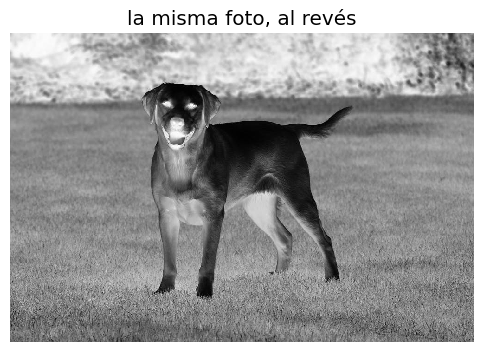

In [13]:
imagen.mostrar(255 - imagen.actual(), titulo="la misma foto, al revés")

### El color son tres números

Hasta aquí todo fue gris, que es un número por punto. El color son tres:
cuánto rojo, cuánto verde y cuánto azul.

Con esos tres cabe cualquier color que hayas visto en una pantalla. Búscate uno.

In [14]:
imagen.mezclador_color()

---

# 3 · Tu música es una lista de números

Un sonido es aire que empuja y jala tu tímpano. Si mides cuánto empuja, muchísimas
veces por segundo, te queda una lista de números.

Aquí está una, vista de muy cerca. Y escuchada.

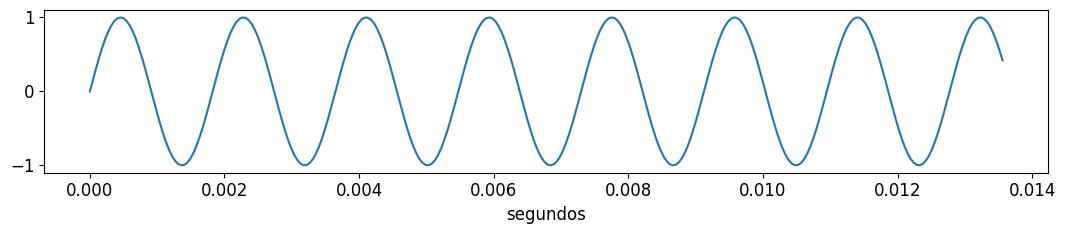

In [16]:
la = sonido.onda(548)

sonido.dibujar_onda(la)
sonido.reproducir(la)

### 🔧 Prueba tú

Un solo número decide qué nota es. Arrástralo.

In [17]:
sonido.deslizador_de_tono()

### Y ahora rómpelo

Si el sonido es una lista, se le puede hacer lo que sea a una lista. Toma menos
números y sale más rápido. Léela del final al principio y sale al revés.

In [18]:
sonido.reproducir(sonido.a_velocidad(la, 2))
sonido.reproducir(sonido.al_reves(sonido.melodia_del_nombre(mi_nombre)))

### Y ahora súmalos

Tres sonidos. Súmalos como sumarías tres números.

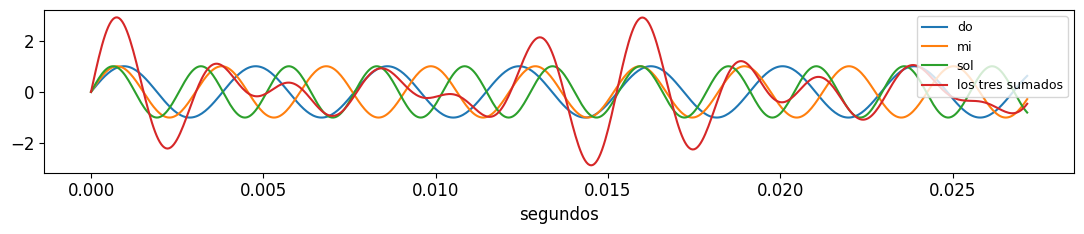

In [19]:
do  = sonido.onda(261.63)
mi  = sonido.onda(329.63)
sol = sonido.onda(392.00)

acorde = do + mi + sol

sonido.dibujar_onda([do, mi, sol, acorde],
                    etiquetas=["do", "mi", "sol", "los tres sumados"],
                    muestras=600)
sonido.reproducir(acorde)

### Lo que llevas

Eso es un acorde de do mayor. No lo compusiste: lo **sumaste**.

Tu nombre, tu cara y ese acorde entraron a la máquina y se convirtieron en lo
mismo: listas de números.

Y a los tres les hiciste exactamente la misma cosa para cambiarlos. Le sumaste
tres lugares del alfabeto a cada letra de tu nombre. Le sumaste setenta niveles
de luz a cada pixel de tu foto. Le sumaste dos ondas más a la primera onda.

Por eso una sola máquina puede tocar música, editar fotos y guardar mensajes. No
tiene tres talentos. Tiene uno.

---

# 4 · ¿Y cómo cabe todo eso en una piedra?

Toma un puñado de arena de playa. Es dióxido de silicio: lo mismo de lo que
está hecho el vidrio de una ventana.

Derrítela. Purifícala hasta que de cada mil millones de átomos solo uno sea de
otra cosa. Te queda un cristal gris que cabe en tu mano.

Ahora graba en su superficie algo miles de veces más delgado que un cabello,
que hace **una sola cosa**: deja pasar la electricidad, o no la deja.

Eso es un **transistor**. Un interruptor sin partes móviles, que se prende y se
apaga mil millones de veces por segundo y nunca se cansa.

En el aparato donde estás leyendo esto hay varios **miles de millones**. Cada
uno, por su cuenta, solo sabe estar prendido o apagado.

Juntos están corriendo esta página ahorita mismo.

In [20]:
prendido = True    # este es un valor booleano
apagado  = False   # este es un valor booleano

print("Para la máquina no se llaman 'prendido' y 'apagado'. Se llaman 1 y 0.")
print("Y no es un apodo. Compruébalo:")
print()
print("   True  == 1   →", True == 1)
print("   False == 0   →", False == 0)

Para la máquina no se llaman 'prendido' y 'apagado'. Se llaman 1 y 0.
Y no es un apodo. Compruébalo:

   True  == 1   → True
   False == 0   → True


### Ocho interruptores

Un interruptor solo tiene dos estados, así que solo puede guardar 0 o 1. Con
ocho ya cabe cualquier número hasta 255.

El truco es que cada columna vale **el doble** que su vecina de la derecha. En
el sistema que ya usas cada columna vale diez veces más, y es diez solo porque
tenemos diez dedos. Por nada más.

**Préndelos con el dedo** y mira qué número sale.

In [22]:
interruptores.tablero()

### Dale play

Ahora míralos contar solos, del 0 al 255. **Mira las columnas, no el número.**

In [23]:
interruptores.contador()

El interruptor de la derecha se prende y se apaga en cada número. El siguiente,
cada dos. El siguiente, cada cuatro.

Cada uno va exactamente al doble de lento que su vecino de la derecha. Eso es
todo lo que significa contar en binario.

En 1679 Gottfried Leibniz lo escribió a mano, sin computadoras y sin
electricidad. Le pareció bello y ya. Fue un juguete sin ningún uso durante
doscientos setenta años, hasta que alguien conectó unos interruptores y
descubrió que el juguete era exactamente lo que la máquina necesitaba.

### Tu nombre, otra vez

En la parte 1 tu nombre era una lista de números. Así es como está guardado de
verdad.

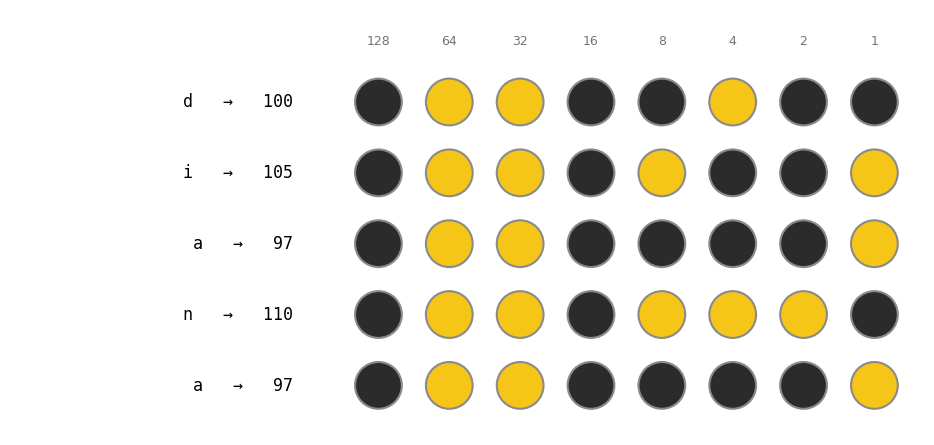

In [29]:
mi_nombre = 'diana'
interruptores.dibujar_palabra(mi_nombre)

### Donde se acaban

Con ocho interruptores el número más grande que existe es este. No hay uno más.

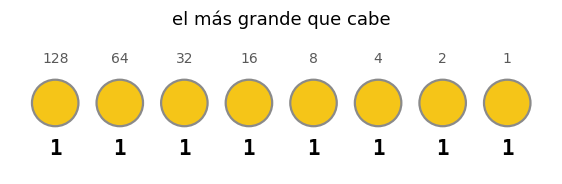

In [32]:
interruptores.dibujar(a_binario(255), etiquetas=TABLA_DE_VALORES,
                      mostrar_bool=False, titulo="el más grande que cabe")

### 🤔 Para pensar

¿Por qué justo 255, y no 256? ¿Y cuántos números distintos caben en ocho
interruptores, contando el cero?

---

# 5 · ¿Y quién suma allá abajo? Nadie

Todo lo que hiciste hoy fue sumar. Le sumaste tres lugares del alfabeto a cada
letra de tu nombre. Le sumaste setenta niveles de luz a cada pixel de tu foto.
Sumaste tres ondas y salió un acorde.

Tres cosas que no se parecen en nada, y la misma operación en las tres.

Y allá abajo, adentro de la piedra, no hay nadie que sepa sumar. Solo hay
interruptores prendidos y apagados.

Así que alguien tuvo que enseñarles. Hoy te toca a ti.

### Tres reglas

Un interruptor solo no sirve de mucho. Lo interesante empieza cuando conectas
dos y decides qué pasa con el de salida.

Hay tres formas de conectarlos, y con esas tres se construyó el mundo entero.
Se llaman **compuertas**, y así se llaman de verdad, en cualquier libro y en
cualquier fábrica: **NOT**, **AND** y **OR**.

Préndelas y apágalas con el dedo. La tabla de cada una se ilumina en el renglón
que estás viviendo, y ahí está *todo* lo que puede pasar. No hay caso
escondido.

In [33]:
compuertas.probador()

### Una cuarta que no es nueva

Con esas tres se puede construir cualquier otra cosa que haga una computadora.
Cualquiera.

Empecemos por una que se prende cuando los dos interruptores son **distintos**.
Se llama **XOR**, y no es una pieza nueva: es NOT, AND y OR conectadas de cierta
forma.

Mueve los interruptores y mira por dónde pasa la corriente.

In [34]:
compuertas.diagrama_xor()

### Las cuatro sumas que existen

Sumar un interruptor más un interruptor. Eso es todo lo que hay:

```
0 + 0 = 0
0 + 1 = 1
1 + 0 = 1
1 + 1 = 10     ← se pasa: escribe 0 y lleva 1
```

Abajo hay dos focos de salida: uno para la suma y otro para el llevo. Recorre
los cuatro casos y fíjate en cuál se prende cada vez.

In [35]:
compuertas.medio_sumador_vivo()

La columna de la suma resultó ser **XOR**. La columna del llevo resultó
ser **AND**.

Nadie inventó una pieza nueva para esto. Las dos ya estaban en tu caja.

### Ocho columnas en fila

Cuando sumas 47 más 38 a mano empiezas por la derecha, y lo que llevas cae en la
siguiente columna. Aquí pasa igual: cada columna recibe tres cosas, el
interruptor de arriba, el de abajo, y el llevo que le mandó su vecina de la
derecha.

Tres cosas no caben en un medio sumador, que solo tiene dos entradas. Así que
cada columna lleva dos: uno suma los dos interruptores, el otro le suma el llevo
que llegó, y una compuerta OR decide si la columna se pasó. Otra vez, ninguna
pieza nueva.

Ocho columnas encadenadas. Préndelas con el dedo y mira el llevo brincar de una
a otra.

Esto que estás moviendo es, literalmente, una pieza que existe dentro de tu
procesador.

In [36]:
compuertas.sumador_vivo()

### ✅ Que se califique solo

Un sumador que acierta una vez pudo tener suerte. Que lo pruebe con **todas** las
sumas posibles de 0 a 127, y que se compare contra el `+` de Python.

In [37]:
aciertos = 0
for a in range(128):
    for b in range(128):
        if a_decimal(compuertas.sumar(a, b)) == a + b:
            aciertos = aciertos + 1

print(f"✅ {aciertos:,} de 16,384 sumas correctas")

✅ 16,384 de 16,384 sumas correctas


Dieciséis mil trescientas ochenta y cuatro sumas, todas correctas.

Ese resultado salió de ocho columnas encadenadas, cada una hecha de dos medios
sumadores y una compuerta OR, cada medio sumador hecho de un XOR y un AND, y el
XOR hecho de NOT, AND y OR.

Adentro de esa cadena no aparece ni una sola vez el signo `+`. El único `+` de
esta página es el de Python, y lo acabas de usar como juez.

Hasta abajo de todo no hay más que interruptores prendidos y apagados. 🎯

### 🔧 Adivina antes de correr

Con ocho interruptores no cabe nada mayor que 255.

¿Qué crees que va a pasar con 255 más 1? Adivina, y luego corre la celda.

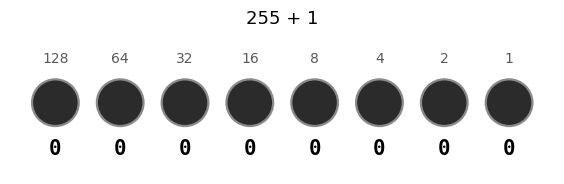

In [38]:
interruptores.dibujar(compuertas.sumar(255, 1), etiquetas=TABLA_DE_VALORES,
                      mostrar_bool=False, titulo="255 + 1")

Todos apagados. Cero.

Eso se llama **desbordamiento**, y no es un detalle académico:

- En **Pac-Man**, el contador de niveles usaba ocho interruptores. Al llegar al
  nivel 256 se desbordó y media pantalla se llenó de símbolos revueltos. Nadie
  pudo pasar de ahí durante años.
- En 1996 el cohete **Ariane 5** se autodestruyó 37 segundos después de despegar.
  Un número no cupo donde lo estaban metiendo. Costó 370 millones de dólares.

Tu sumador tiene exactamente el mismo límite que ellos. No porque esté mal hecho:
porque los interruptores se acaban.

### 🤔 Para pensar

Si un interruptor solo puede estar prendido o apagado, no hay dónde poner el
signo menos. ¿Cómo guardarías un número **negativo**?

---

# 6 · Las capas

Tú armaste un sumador con compuertas. Python trae un `+` que ya venía hecho.

Hacen lo mismo. ¿Para qué existen los dos? Corre esto.

In [39]:
torre.comparar_velocidad()

   tu sumador:             5.3 microsegundos
   el + de Python:      0.0218 microsegundos

   El tuyo es unas 244 veces más lento.


### Por qué

Tu sumador **simula** compuertas usando software, que a su vez corre sobre
compuertas de verdad grabadas en silicio, que hacen la misma operación miles de
millones de veces por segundo.

Armaste una computadora dentro de una computadora. Por eso es lenta, y por eso
valió la pena: pudiste verla por dentro.

El `+` de Python no es más listo que el tuyo. Solo está más abajo en la torre.

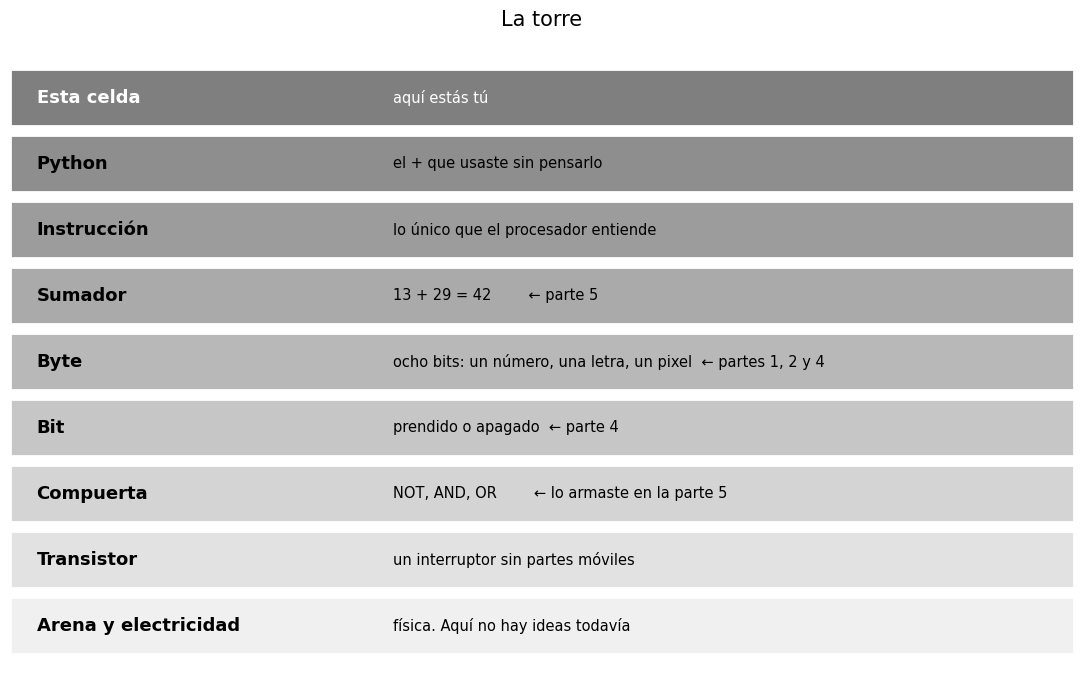

In [28]:
torre.dibujar()

### Lo que se aprende bajando

Cada capa de esa torre existe por una sola razón: **para que no tengas que pensar
en la de abajo**.

El que escribe un videojuego no piensa en transistores. El que diseña
transistores no piensa en videojuegos. Y así funciona todo, hasta el día que algo
se rompe y alguien tiene que saber bajar.

Hoy bajaste hasta el fondo. Abriste tu nombre, tu cara y tu música, tocaste el
interruptor, lo conectaste, le enseñaste a contar, le enseñaste a sumar, y
volviste a subir.

La piedra ya cuenta.

---

## 🤔 Y sin embargo

Tu sumador no ha hecho nada por su cuenta.

Se quedó ahí, quieto, esperando a que tú corrieras la celda. Sabe sumar, pero no
sabe **cuándo** sumar, ni **qué** sumar, ni qué hacer después.

Le falta algo que no es una compuerta ni un número:

> Una receta. Alguien que le diga qué hacer, y en qué orden.

Eso es la siguiente presentación: **la venida del proceso**.